In [2]:
import numpy as np

fname = "Lx_24_Nd_500_NT_17280_px_0.0_MPI_hexagonal6.npz"

# npzファイルを開く
data = np.load(fname)

# キー一覧を表示
print("keys:", data.files)

# 各キーの shape や dtype を確認
for k in data.files:
    arr = data[k]
    print(f"{k}: shape={arr.shape}, dtype={arr.dtype}")

# 例えば pg をちょっと見る
print("pg[:10] =", data["pg"][:10])


keys: ['pg', 'TEE1_ave', 'TEE1_err', 'TEE1_var', 'TEE2_ave', 'TEE2_err', 'TEE2_var', 'TEE3_ave', 'TEE3_err', 'TEE3_var', 'TEE4_ave', 'TEE4_err', 'TEE4_var', 'TEE5_ave', 'TEE5_err', 'TEE5_var', 'TEE6_ave', 'TEE6_err', 'TEE6_var']
pg: shape=(21,), dtype=float64
TEE1_ave: shape=(21,), dtype=float64
TEE1_err: shape=(21,), dtype=float64
TEE1_var: shape=(21,), dtype=float64
TEE2_ave: shape=(21,), dtype=float64
TEE2_err: shape=(21,), dtype=float64
TEE2_var: shape=(21,), dtype=float64
TEE3_ave: shape=(21,), dtype=float64
TEE3_err: shape=(21,), dtype=float64
TEE3_var: shape=(21,), dtype=float64
TEE4_ave: shape=(21,), dtype=float64
TEE4_err: shape=(21,), dtype=float64
TEE4_var: shape=(21,), dtype=float64
TEE5_ave: shape=(21,), dtype=float64
TEE5_err: shape=(21,), dtype=float64
TEE5_var: shape=(21,), dtype=float64
TEE6_ave: shape=(21,), dtype=float64
TEE6_err: shape=(21,), dtype=float64
TEE6_var: shape=(21,), dtype=float64
pg[:10] = [0.7  0.71 0.72 0.73 0.74 0.75 0.76 0.77 0.78 0.79]


In [3]:
import numpy as np
from collections import defaultdict
import re, math

# --- 1) slurmログをパースして {pg: list of [TEE1..TEE6]} を作る ---
bucket = defaultdict(list)
pat = re.compile(r"pg=\s*([0-9.]+).*?TEE1=\s*([-0-9.]+).*?TEE2=\s*([-0-9.]+).*?"
                 r"TEE3=\s*([-0-9.]+).*?TEE4=\s*([-0-9.]+).*?TEE5=\s*([-0-9.]+).*?TEE6=\s*([-0-9.]+)")
with open("slurm-2647584.out") as f:
    for line in f:
        m = pat.search(line)
        if m:
            pg = float(m.group(1))
            tees = list(map(float, m.groups()[1:]))  # 6個
            bucket[pg].append(tees)

pg = np.array(sorted(bucket.keys()))
stack = np.array([bucket[p] for p in pg], dtype=float)   # shape=(nP, nSamples, 6)

# --- 2) 分散とそのブートストラップ標準誤差を推定 ---
def bootstrap_var(x, nboot=1000, rng=np.random.default_rng(0)):
    x = np.asarray(x)
    n = len(x)
    if n <= 3:
        return np.var(x, ddof=1), np.nan  # サンプル少な過ぎ
    vs = []
    for _ in range(nboot):
        idx = rng.integers(0, n, n)
        vs.append(np.var(x[idx], ddof=1))
    return np.var(x, ddof=1), np.std(vs, ddof=1)

var6  = np.zeros((len(pg), 6))
dvar6 = np.zeros((len(pg), 6))
for i in range(len(pg)):
    for k in range(6):
        v, dv = bootstrap_var(stack[i,:,k], nboot=1000)
        var6[i,k]  = v
        dvar6[i,k] = dv

# これを npz に保存（pyfssa にそのまま渡せる形）
out = {"pg": pg}
for k in range(6):
    out[f"TEE{k+1}_var"] = var6[:,k]
    out[f"TEE{k+1}_err"] = dvar6[:,k]          # ← 平均の誤差ではなく、分散の標準誤差！
np.savez_compressed("from_log_var_boot.npz", **out)


In [4]:
import numpy as np

fname = "from_log_var_boot.npz"

# npzファイルを開く
data = np.load(fname)

# キー一覧を表示
print("keys:", data.files)

# 各キーの shape や dtype を確認
for k in data.files:
    arr = data[k]
    print(f"{k}: shape={arr.shape}, dtype={arr.dtype}")

# 例えば pg をちょっと見る
print("pg =", data["pg"][:21])
print("TEE2_var =", data["TEE2_var"][:21])
print("TEE2_err =", data["TEE2_err"][:21])
print("TEE3_var =", data["TEE3_var"][:21])
print("TEE3_err =", data["TEE3_err"][:21])
print("TEE4_var =", data["TEE4_var"][:21])
print("TEE4_err =", data["TEE4_err"][:21])

keys: ['pg', 'TEE1_var', 'TEE1_err', 'TEE2_var', 'TEE2_err', 'TEE3_var', 'TEE3_err', 'TEE4_var', 'TEE4_err', 'TEE5_var', 'TEE5_err', 'TEE6_var', 'TEE6_err']
pg: shape=(21,), dtype=float64
TEE1_var: shape=(21,), dtype=float64
TEE1_err: shape=(21,), dtype=float64
TEE2_var: shape=(21,), dtype=float64
TEE2_err: shape=(21,), dtype=float64
TEE3_var: shape=(21,), dtype=float64
TEE3_err: shape=(21,), dtype=float64
TEE4_var: shape=(21,), dtype=float64
TEE4_err: shape=(21,), dtype=float64
TEE5_var: shape=(21,), dtype=float64
TEE5_err: shape=(21,), dtype=float64
TEE6_var: shape=(21,), dtype=float64
TEE6_err: shape=(21,), dtype=float64
pg = [0.7  0.71 0.72 0.73 0.74 0.75 0.76 0.77 0.78 0.79 0.8  0.81 0.82 0.83
 0.84 0.85 0.86 0.87 0.88 0.89 0.9 ]
TEE2_var = [0.00037377 0.00056611 0.0006318  0.00091905 0.00129875 0.00200333
 0.00279115 0.00453735 0.00594738 0.00758096 0.00759114 0.00684237
 0.00472615 0.00307917 0.00274834 0.00192102 0.00153818 0.00115939
 0.00097333 0.00067782 0.00046904]
TEE2_err

In [5]:
import numpy as np

# ===== 入力 =====
AVE_NPZ = "Lx_24_Nd_500_NT_17280_px_0.0_MPI_hexagonal6.npz"   # 例: 'pg', 'TEE{i}_ave', 'TEE{i}_ave_err' を含む
VAR_NPZ = "from_log_var_boot.npz"   # 例: 'pg', 'TEE{i}_var', 'TEE{i}_err'     を含む
OUT_NPZ = "fss_merged.npz"

# あなたが指定するサイズ（数値）。例：TEE2=√12, TEE3=√18 など
SIZE = {
    "TEE1": np.sqrt(6),
    "TEE2": np.sqrt(12),
    "TEE3": np.sqrt(18),
    "TEE4": np.sqrt(24),   # ←必要な値を入れてください
    "TEE5": np.sqrt(30),
    "TEE6": np.sqrt(36),
}

# ===== マージ処理 =====
za = np.load(AVE_NPZ)
zv = np.load(VAR_NPZ)

pg_a = za["pg"]
pg_v = zv["pg"]
if not np.allclose(pg_a, pg_v):
    raise ValueError("pg が ave と var で一致していません。揃えてから実行してください。")

out = {"pg": pg_a}

for i in range(1, 7):
    key = f"TEE{i}"

    # サイズ（あなた指定の数値を保存）
    if key not in SIZE:
        raise KeyError(f"SIZE に {key} の指定がありません。")
    out[f"{key}_size"] = float(SIZE[key])

    # ave と誤差（誤差が無ければスキップでOK）
    out[f"{key}_ave"] = za[f"{key}_ave"]
    if f"{key}_err" in za:
        out[f"{key}_ave_err"] = za[f"{key}_err"]

    # var と誤差（あなたの形式に合わせて *_err を拾う）
    out[f"{key}_var"] = zv[f"{key}_var"]
    if f"{key}_err" in zv:               # 例：分散のブート誤差を 'TEE{i}_err' で保存している
        out[f"{key}_var_err"] = zv[f"{key}_err"]
    elif f"{key}_err" in zv:         # 別名対応
        out[f"{key}_var_err"] = zv[f"{key}_err"]

# 保存
np.savez_compressed(OUT_NPZ, **out)
print(f"Wrote {OUT_NPZ} with keys:", list(out.keys()))


Wrote fss_merged.npz with keys: ['pg', 'TEE1_size', 'TEE1_ave', 'TEE1_ave_err', 'TEE1_var', 'TEE1_var_err', 'TEE2_size', 'TEE2_ave', 'TEE2_ave_err', 'TEE2_var', 'TEE2_var_err', 'TEE3_size', 'TEE3_ave', 'TEE3_ave_err', 'TEE3_var', 'TEE3_var_err', 'TEE4_size', 'TEE4_ave', 'TEE4_ave_err', 'TEE4_var', 'TEE4_var_err', 'TEE5_size', 'TEE5_ave', 'TEE5_ave_err', 'TEE5_var', 'TEE5_var_err', 'TEE6_size', 'TEE6_ave', 'TEE6_ave_err', 'TEE6_var', 'TEE6_var_err']


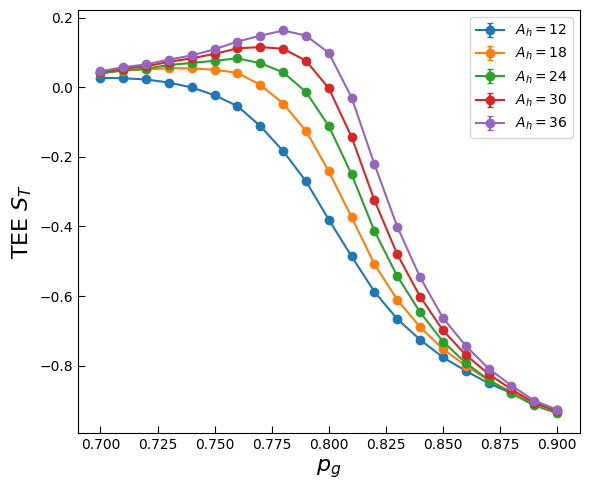

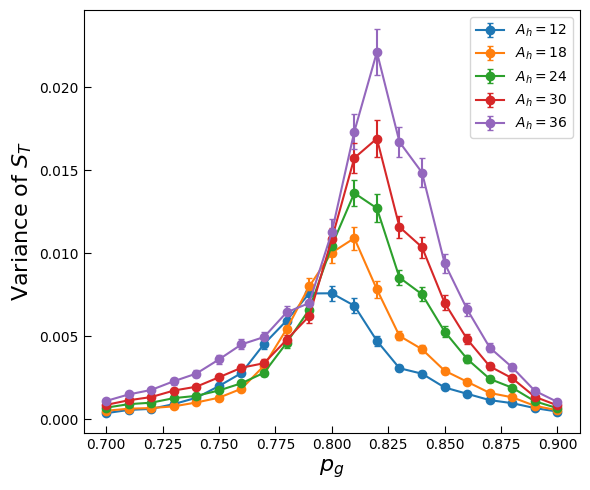

In [7]:
# ave/var を誤差つきで可視化（凡例は *_size）
import numpy as np
import matplotlib.pyplot as plt

NPZ_PATH = "fss_merged.npz"   # ここをあなたのファイルに
SERIES   = [2, 3, 4, 5, 6] # 描きたい TEE 番号

z  = np.load(NPZ_PATH)
pg = z["pg"].astype(float)

def get(key):  # 存在チェックつき取得
    if key not in z:
        raise KeyError(f"'{key}' が {NPZ_PATH} にありません")
    return z[key].astype(float)


labels = [r"$A_h=12$", r"$A_h=18$", r"$A_h=24$", r"$A_h=30$", r"$A_h=36$"]

# SERIES と labels の対応を作る（順番対応）
if len(labels) < len(SERIES):
    raise ValueError("labels の数が SERIES より少ないです。対応する分だけ用意してください。")
label_map = {s: labels[idx] for idx, s in enumerate(SERIES)}

# --- ave ± err ---
fig, ax = plt.subplots(figsize=(6,5))
for i in SERIES:
    ave    = get(f"TEE{i}_ave")
    aveerr = get(f"TEE{i}_ave_err")
    ax.errorbar(pg, ave, yerr=aveerr, fmt='o-', capsize=2, label=label_map[i])

ax.set_xlabel("$p_g$",fontsize=16)
ax.set_ylabel("TEE $S_{T}$",fontsize=16)
#ax.set_title("Average with error")
ax.legend(title="")

# 目盛りはメジャーのみを内側へ（補助目盛りは使わない）
ax.tick_params(direction='in', which='major', length=5)
ax.minorticks_off()  # 補助目盛を完全に無効化
ax.tick_params(which='minor', bottom=False, left=False, top=False, right=False)

fig.tight_layout()
fig.savefig("TEE_ave_px_0.png", dpi=300, bbox_inches="tight")
plt.show()


# --- var ± err ---
fig, ax = plt.subplots(figsize=(6,5))
for i in SERIES:
    var    = get(f"TEE{i}_var")
    varerr = get(f"TEE{i}_var_err")
    if len(var) != len(pg) or len(varerr) != len(pg):
        raise ValueError(f"TEE{i} の長さが pg と一致しません")
    ax.errorbar(pg, var, yerr=varerr, fmt='o-', capsize=2, label=label_map[i])
ax.set_xlabel("$p_g$",fontsize=16)
ax.set_ylabel("Variance of $S_{T}$",fontsize=16)
#ax.set_title("Average with error")
ax.legend(title="")

# 目盛りはメジャーのみを内側へ（補助目盛りは使わない）
ax.tick_params(direction='in', which='major',length=5)
ax.minorticks_off()  # 補助目盛を完全に無効化
ax.tick_params(which='minor', bottom=False, left=False, top=False, right=False)

fig.tight_layout()
fig.savefig("TEE_var_px_0.png", dpi=300, bbox_inches="tight")
plt.show()


/home/kataoka/anaconda3/envs/pyfssa_env/lib/python3.8/site-packages/fssa/fssa.py:165: RuntimeWarning: rho_c is out of range
  warnings.warn("rho_c is out of range", RuntimeWarning)



=== Variance FSS (from_log_var_boot.npz) ===
pc   = 0.875088306 ± 0.015353350
nu   = 1.297652988 ± 0.189166655
zeta = 2.790085538 ± 0.658774849
S     = 3.256300


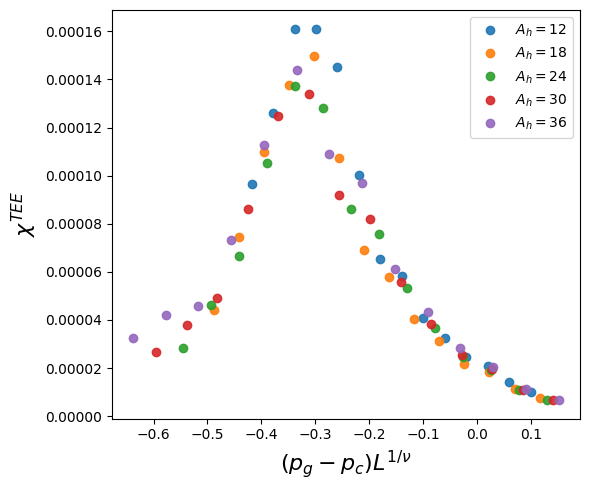

In [154]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
import numpy as np
import fssa
import matplotlib.pyplot as plt

# ======================
# 入力
# ======================
npz_path = "fss_merged.npz"   # ブートストラップで作ったnpz
# Lは √(セル数) を例として使用（あなたの流儀に合わせて変更）
#L_list   = [np.sqrt(18), np.sqrt(36), np.sqrt(54), np.sqrt(72), np.sqrt(90), np.sqrt(108)]
L_list   = [np.sqrt(36), np.sqrt(54), np.sqrt(72), np.sqrt(90), np.sqrt(108)]
# TEEのどれを使うか（L_listと同数・同順に合わせる）
#TEE_cols = [1,2, 3, 4, 5, 6]  # = TEE2..TEE6 を使う例
TEE_cols = [2, 3, 4, 5, 6]  # = TEE2..TEE6 を使う例

# クリティカル窓（まず少し広め→収束後に狭めるのが吉）
pc0   = 0.84
width = 0.07

# ζを固定すると相関が切れて安定（推奨）
FIX_ZETA = False
ZETA_VAL = 1.8
# ζを自由にしたい場合は False にして下の zeta0 を初期値とする
zeta0    = 2



rho_c0, nu0 = 0.85, 1.7


# 誤差フロア（ゼロ重み回避）
ERR_FLOOR_REL = 1e-3

# ======================
# データ読み込み（分散とそのSE）
# ======================
dat = np.load(npz_path)
pg = dat["pg"]

# 例：TEE2..TEE6 を使う
def col_to_key(c): return f"TEE{c}"
a_var  = np.array([dat[f"{col_to_key(c)}_var"] for c in TEE_cols], float)  # shape=(nL,nP)
da_var = np.array([dat[f"{col_to_key(c)}_var_err"] for c in TEE_cols], float)

# --- p窓 ---
mask = (pg >= pc0 - width) & (pg <= pc0 + width)
pg_use     = pg[mask]
a_var_use  = a_var[:,  mask]
da_var_use = da_var[:, mask]

# --- p を昇順に並び替え（重要） ---
order = np.argsort(pg_use)
pg_use     = pg_use[order]
a_var_use  = a_var_use[:,  order]
da_var_use = da_var_use[:, order]

# --- 誤差フロア ---
eps = ERR_FLOOR_REL * np.nanmedian(np.abs(a_var_use))
da_var_use = np.maximum(da_var_use, eps)

# ======================
# 粗探索で初期値（pc, nu）を作る
# ======================
"""rhos = np.linspace(pg_use.min(), pg_use.max(), 31)
nus  = np.linspace(0.8, 3.0, 30)
bestS, rho_c0, nu0 = np.inf, None, None

for rh in rhos:
    for nv in nus:
        zeta = ZETA_VAL if FIX_ZETA else zeta0
        xs, ys, dys = fssa.scaledata(L_list, pg_use, a_var_use, da_var_use, rh, nv, zeta)
        S = fssa.quality(xs, ys, dys)
        if S < bestS and np.isfinite(S):
            bestS, rho_c0, nu0 = S, rh, nv

print(f"[coarse] pc0={rho_c0:.6f}, nu0={nu0:.4f}, S={bestS:.4f}")"""

# ======================
# autoscale 本番
# ======================
if FIX_ZETA:
    ret = fssa.autoscale(L_list, pg_use, a_var_use, da_var_use,
                         rho_c0=rho_c0, nu0=nu0, zeta0=ZETA_VAL)
    # ζ固定
    ret.zeta  = ZETA_VAL
    ret.dzeta = 0.0
else:
    ret = fssa.autoscale(L_list, pg_use, a_var_use, da_var_use,
                         rho_c0=rho_c0, nu0=nu0, zeta0=zeta0)

# スケール変換（コラプス座標）
xs, ys, dys = fssa.scaledata(L_list, pg_use, a_var_use, da_var_use,
                             ret.rho, ret.nu, ret.zeta)

# 評価関数
from fssa import quality
S_val = quality(xs, ys, dys)

# ======================
# 結果表示
# ======================
print("\n=== Variance FSS (from_log_var_boot.npz) ===")
print(f"pc   = {ret.rho:.9f} ± {getattr(ret, 'drho', np.nan):.9f}")
print(f"nu   = {ret.nu:.9f} ± {getattr(ret, 'dnu',  np.nan):.9f}")
print(f"zeta = {ret.zeta:.9f} ± {getattr(ret, 'dzeta', np.nan):.9f}" + (" (FIXED)" if FIX_ZETA else ""))
print(f"S     = {S_val:.6f}")


# ======================
# プロット（コラプス後）
# ======================
fig, ax = plt.subplots(figsize=(6,5))
labels = [r"$A_h=12$", r"$A_h=18$", r"$A_h=24$", r"$A_h=30$", r"$A_h=36$"]
for i, (L, label) in enumerate(zip(L_list, labels)):
    """ax.errorbar(xs.T[:, i], ys.T[:, i], yerr=dys.T[:, i],
                fmt='o', ms=5, capsize=3, label=label, alpha=0.9)"""
    ax.plot(xs.T[:, i], ys.T[:, i],'o', label=label, alpha=0.9)
ax.set_xlabel(r"$(p_g-p_c)L^{1/\nu}$",fontsize=16)
ax.set_ylabel(r"$\chi^{TEE}$",fontsize=16)
ax.legend( fontsize=10)
ax.grid(False)
fig.tight_layout()
fig.savefig("TEE_collapse_px_0.png", dpi=300, bbox_inches="tight")
plt.show()


=== zeta from peak-height scaling ===
mode(L_eff) = sqrtAh, SERIES = ['TEE2', 'TEE3', 'TEE4', 'TEE5', 'TEE6']
TEE2: L_eff= 3.464, peak=0.0078575 ± 0.00035  (at g≈0.7957 ± 0.0057)
TEE3: L_eff= 4.243, peak=0.0109716 ± 0.00059  (at g≈0.8083 ± 0.0037)
TEE4: L_eff= 4.899, peak=0.0137507 ± 0.00072  (at g≈0.8124 ± 0.0043)
TEE5: L_eff= 5.477, peak=0.0170977 ± 0.00098  (at g≈0.8179 ± 0.0041)
TEE6: L_eff= 6.000, peak=0.0221359 ± 0.0014  (at g≈0.8200 ± 0.0003)

ζ = 1.826327 ± 0.123121


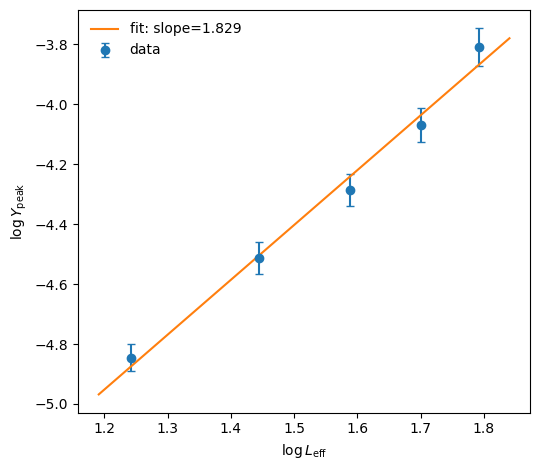

In [61]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-

import numpy as np
import matplotlib.pyplot as plt

# ========= 設定 =========
NPZ_PATH = "from_log_var_boot.npz"   # ← あなたの npz
SERIES_KEYS = ["TEE2","TEE3","TEE4","TEE5","TEE6"]  # 使う系列（有効サイズに対応）

# 有効サイズの定義（Ah: 面積, sqrtAh: 長さスケール）
EFF_SIZE_MODE = "sqrtAh"   # "sqrtAh"（推奨） or "Ah"
AH_MAP = {"TEE1":6, "TEE2":12, "TEE3":18, "TEE4":24, "TEE5":30, "TEE6":36}

# ピーク抽出のブートストラップ（分散曲線の誤差を反映）
N_BOOT_PEAK = 2000
# ζ 誤差評価のモンテカルロ（ピーク平均±SEから再サンプリング）
N_BOOT_ZETA = 5000
RNG = np.random.default_rng(0)

# ========= 関数 =========
def eff_size_from_keys(keys, mode="sqrtAh"):
    Ah = np.array([AH_MAP[k] for k in keys], dtype=float)
    if mode == "Ah":
        return Ah
    elif mode == "sqrtAh":
        return np.sqrt(Ah)
    else:
        raise ValueError("EFF_SIZE_MODE must be 'Ah' or 'sqrtAh'.")

def peak_bootstrap(g, y, yerr, nboot=1000, rng=None):
    """
    分散曲線 y(g) と 1σ誤差 yerr から、ピーク高さのブートストラップ平均・標準偏差を返す。
    """
    if rng is None:
        rng = np.random.default_rng()
    peaks = []
    peak_pos = []
    yerr = np.maximum(yerr, 1e-12)
    for _ in range(nboot):
        yb = y + rng.normal(0.0, yerr)
        i = int(np.argmax(yb))
        peaks.append(max(yb[i], 1e-16))
        peak_pos.append(g[i])
    peaks = np.asarray(peaks)
    peak_pos = np.asarray(peak_pos)
    return peaks.mean(), peaks.std(ddof=1), peak_pos.mean(), peak_pos.std(ddof=1)

def zeta_from_loglog_mc(L_eff, Y_mean, Y_se, nboot=5000, rng=None):
    """
    各サイズのピーク平均 Y_mean と 1σ (標準誤差) Y_se から、
    Y ~ Normal(Y_mean, Y_se) を再サンプリングして log–log 直線の傾き ζ をブートストラップ。
    """
    if rng is None:
        rng = np.random.default_rng()
    x = np.log(L_eff)
    zetas = []
    for _ in range(nboot):
        # ピーク高さの再サンプリング（負にならないようクリップ）
        ys = np.maximum(rng.normal(Y_mean, Y_se), 1e-16)
        y = np.log(ys)
        # 単純な最小二乗直線（重みはピーク再サンプルに吸収されている前提）
        coeff = np.polyfit(x, y, deg=1)
        zetas.append(coeff[0])
    zetas = np.asarray(zetas)
    return zetas.mean(), zetas.std(ddof=1)

# ========= データ読み込み =========
dat = np.load(NPZ_PATH)
g = dat["pg"].astype(float)

# 系列ごとのピーク抽出（平均±SE、ピーク位置も参考出力）
peak_means, peak_ses, peak_pos_mean, peak_pos_se = [], [], [], []
for key in SERIES_KEYS:
    y   = dat[f"{key}_var"].astype(float)
    dy  = dat[f"{key}_err"].astype(float)
    # 必要に応じて p 窓でマスク
    # mask = (g >= 0.78) & (g <= 0.90)
    # y, dy = y[mask], dy[mask]; g_use = g[mask]
    g_use = g
    mu, se, xpos_mu, xpos_se = peak_bootstrap(g_use, y, dy, nboot=N_BOOT_PEAK, rng=RNG)
    peak_means.append(mu)
    peak_ses.append(se)
    peak_pos_mean.append(xpos_mu)
    peak_pos_se.append(xpos_se)

peak_means = np.asarray(peak_means)
peak_ses   = np.asarray(peak_ses)
peak_pos_mean = np.asarray(peak_pos_mean)
peak_pos_se   = np.asarray(peak_pos_se)

# ========= 有効サイズ配列 =========
L_eff = eff_size_from_keys(SERIES_KEYS, mode=EFF_SIZE_MODE)

# ========= ζ と誤差（ブートストラップMC） =========
zeta_mean, zeta_std = zeta_from_loglog_mc(L_eff, peak_means, peak_ses,
                                          nboot=N_BOOT_ZETA, rng=RNG)

print("=== zeta from peak-height scaling ===")
print(f"mode(L_eff) = {EFF_SIZE_MODE}, SERIES = {SERIES_KEYS}")
for k, Le, mu, se, gx, gs in zip(SERIES_KEYS, L_eff, peak_means, peak_ses, peak_pos_mean, peak_pos_se):
    print(f"{k:>4s}: L_eff={Le:>6.3f}, peak={mu:.6g} ± {se:.2g}  (at g≈{gx:.4f} ± {gs:.4f})")
print(f"\nζ = {zeta_mean:.6f} ± {zeta_std:.6f}")

# ========= 可視化（log–log 図） =========
fig, ax = plt.subplots(figsize=(5.5,4.8))
ax.errorbar(np.log(L_eff), np.log(peak_means),
            yerr=peak_ses/np.maximum(peak_means,1e-16),  # d(logY) ≈ dY/Y
            fmt='o', capsize=3, label="data")
# フィット直線（平均で一発）
coef = np.polyfit(np.log(L_eff), np.log(peak_means), deg=1)
xx = np.linspace(np.log(L_eff.min()*0.95), np.log(L_eff.max()*1.05), 100)
yy = np.polyval(coef, xx)
ax.plot(xx, yy, '-', label=f"fit: slope={coef[0]:.3f}")

ax.set_xlabel(r"$\log L_{\rm eff}$")
ax.set_ylabel(r"$\log Y_{\rm peak}$")
ax.legend(frameon=False)
ax.grid(False)
fig.tight_layout()
fig.savefig("zeta_peakheight_loglog.png", dpi=300, bbox_inches="tight")
plt.show()


=== zeta from peak-height scaling (quadratic+bootstrap) ===
mode(L_eff)=sqrtAh, SERIES=['TEE2', 'TEE3', 'TEE4', 'TEE5', 'TEE6']
TEE2: L_eff= 3.464 | peak=0.00794565 ± 0.00036 | g*≈0.79610 ± 0.00361
TEE3: L_eff= 4.243 | peak=0.011129 ± 0.00059 | g*≈0.80678 ± 0.00177
TEE4: L_eff= 4.899 | peak=0.0139652 ± 0.00071 | g*≈0.81329 ± 0.00196
TEE5: L_eff= 5.477 | peak=0.0174381 ± 0.00095 | g*≈0.81642 ± 0.00166
TEE6: L_eff= 6.000 | peak=0.0221701 ± 0.0014 | g*≈0.81962 ± 0.00087

ζ (MC)   = 1.820004 ± 0.121852
ζ (wOLS) = 1.762189   （参考：重み付きOLSの傾き）


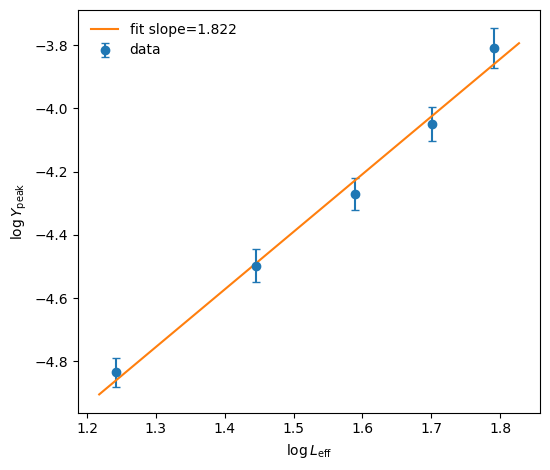

In [62]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-

import numpy as np
import matplotlib.pyplot as plt

# ========= 設定 =========
NPZ_PATH = "from_log_var_boot.npz"
SERIES_KEYS = ["TEE2","TEE3","TEE4","TEE5","TEE6"]  # 有効サイズに対応
EFF_SIZE_MODE = "sqrtAh"   # "sqrtAh" or "Ah"
AH_MAP = {"TEE1":6, "TEE2":12, "TEE3":18, "TEE4":24, "TEE5":30, "TEE6":36}

# --- ピーク抽出 ---
N_BOOT_PEAK = 2000     # 分散曲線→ピーク高さ/位置のブートストラップ
# --- ζ の誤差 ---
N_BOOT_ZETA = 5000     # ピーク高さ±SEからのMC
RNG = np.random.default_rng(0)

# ========= 関数 =========
def eff_size_from_keys(keys, mode="sqrtAh"):
    Ah = np.array([AH_MAP[k] for k in keys], dtype=float)
    return Ah if mode == "Ah" else np.sqrt(Ah)

def quad_vertex(x0, y0, x1, y1, x2, y2):
    """3点 (x0,y0),(x1,y1),(x2,y2) の二次式頂点 (xv, yv)。a≃0 なら中心点にフォールバック。"""
    denom = (x0-x1)*(x0-x2)*(x1-x2)
    if np.isclose(denom, 0.0):
        return x1, y1
    a = (x2*(y1-y0) + x1*(y0-y2) + x0*(y2-y1)) / denom
    b = (x2*x2*(y0-y1) + x1*x1*(y2-y0) + x0*x0*(y1-y2)) / denom
    if np.isclose(a, 0.0):
        return x1, y1
    xv = -b/(2*a)
    # 範囲外に飛んだら中央点
    if not (min(x0,x2) <= xv <= max(x0,x2)):
        xv = x1
    yv = a*xv*xv + b*xv + (y0 - a*x0*x0 - b*x0)  # c を消去して評価
    return xv, yv

def peak_bootstrap_quadratic(g, y, yerr, nboot=1000, rng=None):
    """
    分散曲線 y(g) に誤差を加えてブートストラップ。
    各試行で argmax 近傍の3点に二次フィットし、サブグリッドのピーク高さ/位置を返す。
    端点に最大が来たらグリッド点を採用。
    """
    if rng is None:
        rng = np.random.default_rng()
    yerr = np.maximum(yerr, 1e-16)
    peaks, xpos = [], []
    n = len(g)
    for _ in range(nboot):
        yb = y + rng.normal(0.0, yerr)
        i = int(np.argmax(yb))
        if 0 < i < n-1:
            xv, yv = quad_vertex(g[i-1], yb[i-1], g[i], yb[i], g[i+1], yb[i+1])
            peaks.append(max(yv, 1e-16))
            xpos.append(xv)
        else:
            peaks.append(max(yb[i], 1e-16))
            xpos.append(g[i])
    peaks = np.asarray(peaks)
    xpos  = np.asarray(xpos)
    return peaks.mean(), peaks.std(ddof=1), xpos.mean(), xpos.std(ddof=1)

def zeta_from_loglog_mc(L_eff, Y_mean, Y_se, nboot=5000, rng=None):
    """Y ~ N(Y_mean, Y_se) を再サンプルし、log–log 直線の傾き ζ をブートストラップ。"""
    if rng is None:
        rng = np.random.default_rng()
    x = np.log(L_eff)
    zetas = []
    for _ in range(nboot):
        ys = np.maximum(rng.normal(Y_mean, Y_se), 1e-16)
        y  = np.log(ys)
        # 最小二乗直線（次数1）。重みは Y_se に反映済みとみなす。
        coeff = np.polyfit(x, y, deg=1)
        zetas.append(coeff[0])
    zetas = np.asarray(zetas)
    return zetas.mean(), zetas.std(ddof=1)

def zeta_weighted_ols(L_eff, Y_mean, Y_se):
    """参考：log–log の重み付きOLS（d(logY) ≈ dY/Y を重みとして使用）。"""
    x = np.log(L_eff)
    y = np.log(np.maximum(Y_mean, 1e-16))
    dy = np.maximum(Y_se, 1e-16)/np.maximum(Y_mean, 1e-16)
    w = 1.0/np.square(dy)
    coeff = np.polyfit(x, y, deg=1, w=w)
    return coeff[0]  # slope

# ========= データ読み込み =========
dat = np.load(NPZ_PATH)
g = dat["pg"].astype(float)

# ========= 系列ごとのピーク抽出 =========
peak_means, peak_ses, peak_pos_mean, peak_pos_se = [], [], [], []
for key in SERIES_KEYS:
    if f"{key}_var" not in dat or f"{key}_err" not in dat:
        raise KeyError(f"npz に {key}_var / {key}_err が見つかりません")
    y  = dat[f"{key}_var"].astype(float)
    dy = dat[f"{key}_err"].astype(float)
    # （必要なら臨界窓でマスク）
    g_use, y_use, dy_use = g, y, dy
    mu, se, gx, gs = peak_bootstrap_quadratic(g_use, y_use, dy_use, nboot=N_BOOT_PEAK, rng=RNG)
    peak_means.append(mu); peak_ses.append(se)
    peak_pos_mean.append(gx); peak_pos_se.append(gs)

peak_means    = np.asarray(peak_means)
peak_ses      = np.asarray(peak_ses)
peak_pos_mean = np.asarray(peak_pos_mean)
peak_pos_se   = np.asarray(peak_pos_se)

# ========= 有効サイズ & ζ =========
if len(SERIES_KEYS) < 3:
    raise ValueError("ζ を推定するには少なくとも3サイズ（3系列）が必要です。")

L_eff = eff_size_from_keys(SERIES_KEYS, mode=EFF_SIZE_MODE)

zeta_mean, zeta_std = zeta_from_loglog_mc(L_eff, peak_means, peak_ses,
                                          nboot=N_BOOT_ZETA, rng=RNG)
zeta_wols = zeta_weighted_ols(L_eff, peak_means, peak_ses)  # 参考

# ========= 出力 =========
print("=== zeta from peak-height scaling (quadratic+bootstrap) ===")
print(f"mode(L_eff)={EFF_SIZE_MODE}, SERIES={SERIES_KEYS}")
for k, Le, mu, se, gx, gs in zip(SERIES_KEYS, L_eff, peak_means, peak_ses, peak_pos_mean, peak_pos_se):
    print(f"{k:>4s}: L_eff={Le:>6.3f} | peak={mu:.6g} ± {se:.2g} | g*≈{gx:.5f} ± {gs:.5f}")
print(f"\nζ (MC)   = {zeta_mean:.6f} ± {zeta_std:.6f}")
print(f"ζ (wOLS) = {zeta_wols:.6f}   （参考：重み付きOLSの傾き）")

# ========= 図（log–log） =========
fig, ax = plt.subplots(figsize=(5.6,4.8))
xlog = np.log(L_eff); ylog = np.log(peak_means)
ylog_err = peak_ses/np.maximum(peak_means,1e-16)  # d(logY) ≈ dY/Y
ax.errorbar(xlog, ylog, yerr=ylog_err, fmt='o', capsize=3, label="data")
# 平均値でのフィット線
coef = np.polyfit(xlog, ylog, deg=1)
xx = np.linspace(xlog.min()*0.98, xlog.max()*1.02, 100)
yy = np.polyval(coef, xx)
ax.plot(xx, yy, '-', label=f"fit slope={coef[0]:.3f}")
ax.set_xlabel(r"$\log L_{\rm eff}$")
ax.set_ylabel(r"$\log Y_{\rm peak}$")
ax.legend(frameon=False)
ax.grid(False)
fig.tight_layout()
fig.savefig("zeta_peakheight_loglog.png", dpi=300, bbox_inches="tight")
plt.show()


In [79]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
import numpy as np
import matplotlib.pyplot as plt
import fssa
from fssa import quality

# ========= 入力 =========
NPZ_PATH   = "from_log_var_boot.npz"
SERIES_KEYS = ["TEE2","TEE3","TEE4","TEE5","TEE6"]  # ← 有効サイズに対応
AH_MAP = {"TEE1":6, "TEE2":12, "TEE3":18, "TEE4":24, "TEE5":30, "TEE6":36}
EFF_SIZE_MODE = "sqrtAh"      # "sqrtAh" or "Ah"
ROUND_P = 6                   # p丸め（重複/ズレ対策）
ERR_FLOOR_REL = 1e-3          # 誤差フロア（ゼロ重み回避）

# ζ は固定（先にピーク高さスケーリングで求めた値を使う）
FIX_ZETA  = True
ZETA_VAL  = 1.82              # ← あなたの結果に合わせて変更OK

# pc–ν のグリッド（必要に応じて調整）
PC_CENTER = 0.86             # 事前推定の中心（外挿や前回結果に合わせて）
PC_HALF_W = 0.1              # ±幅
NU_MIN, NU_MAX = 1.1, 2.6

N_PC = 121
N_NU = 121

# ========= ユーティリティ =========
def eff_size(keys, mode="sqrtAh"):
    Ah = np.array([AH_MAP[k] for k in keys], float)
    return Ah if mode == "Ah" else np.sqrt(Ah)

# ========= データ読み込み & 整形 =========
dat = np.load(NPZ_PATH)
pg  = np.round(dat["pg"].astype(float), ROUND_P)

# a=var, da=そのSE を (nL, nP) で作る
A = []; D = []
for k in SERIES_KEYS:
    if f"{k}_var" not in dat or f"{k}_err" not in dat:
        raise KeyError(f"{k}_var / {k}_err が npz にありません")
    A.append(dat[f"{k}_var"].astype(float))
    D.append(dat[f"{k}_err"].astype(float))
A = np.array(A)  # (nL, nP)
D = np.array(D)

# p を昇順に並べ替え & 同一pを平均統合（丸めで束ねる）
ordr = np.argsort(pg)
pg, A, D = pg[ordr], A[:, ordr], D[:, ordr]
uniq, idx = np.unique(pg, return_inverse=True)
A2 = np.stack([np.nanmean(A[:, idx==j], axis=1) for j in range(len(uniq))], axis=1)
D2 = np.stack([np.nanmean(D[:, idx==j], axis=1) for j in range(len(uniq))], axis=1)
pg = uniq.copy()

# 誤差フロア
eps = ERR_FLOOR_REL * np.nanmedian(np.abs(A2))
D2 = np.maximum(D2, eps)

# 窓（ここではグリッドが全体をカバーするので、後で各 pc に合わせて抽出）
L_list = eff_size(SERIES_KEYS, mode=EFF_SIZE_MODE).tolist()

# ========= グリッド評価 =========
pc_grid = np.linspace(PC_CENTER-PC_HALF_W, PC_CENTER+PC_HALF_W, N_PC)
nu_grid = np.linspace(NU_MIN, NU_MAX, N_NU)

Smap = np.full((N_NU, N_PC), np.nan)  # 行=nu, 列=pc（imshowの都合）
best = (np.inf, None, None)

for i, nu in enumerate(nu_grid):
    for j, pc in enumerate(pc_grid):
        # PC を中心に“使える p”だけ抽出（全Lで有限 & da>0 の列のみ残す）
        mask = (pg >= pc-PC_HALF_W) & (pg <= pc+PC_HALF_W)
        if mask.sum() < 8:
            continue
        P  = pg[mask]
        Ause = A2[:, mask]
        Duse = D2[:, mask]

        # 列ごと健全性チェック
        good = np.all(np.isfinite(Ause), axis=0) & np.all(np.isfinite(Duse), axis=0) & np.all(Duse > 0, axis=0)
        if good.sum() < 6:
            continue
        P, Ause, Duse = P[good], Ause[:, good], Duse[:, good]

        # 昇順整列
        o = np.argsort(P)
        P, Ause, Duse = P[o], Ause[:, o], Duse[:, o]

        try:
            zeta = ZETA_VAL if FIX_ZETA else ZETA_VAL  # 必要なら自由化
            xs, ys, dys = fssa.scaledata(L_list, P, Ause, Duse, pc, nu, zeta)
            S = quality(xs, ys, dys)
            Smap[i, j] = S
            if np.isfinite(S) and S < best[0]:
                best = (S, pc, nu)
        except Exception:
            pass

print("Best by grid search:")
print(f"S={best[0]:.4f}, pc={best[1]:.6f}, nu={best[2]:.6f}, zeta={'fixed '+str(ZETA_VAL) if FIX_ZETA else 'free'}")

# ========= ヒートマップ描画 =========
fig, ax = plt.subplots(figsize=(6.6,5.2))
# imshow 用に軸エッジを作成
extent = [pc_grid.min(), pc_grid.max(), nu_grid.min(), nu_grid.max()]
im = ax.imshow(Smap, origin='lower', aspect='auto', extent=extent, cmap='viridis')
cbar = plt.colorbar(im, ax=ax)
cbar.set_label("S (quality)")

# 等高線（任意レベル）
try:
    # pcolormesh用の格子（imshowでもOKだがcontourでNaNに注意）
    PC, NU = np.meshgrid(pc_grid, nu_grid)
    levels = np.nanpercentile(Smap[np.isfinite(Smap)], [5, 10, 20, 40, 60])
    cs = ax.contour(PC, NU, Smap, levels=levels, colors='w', linewidths=0.8)
    ax.clabel(cs, fmt="%.2f", fontsize=8)
except Exception:
    pass

# 最小点をマーク
if best[1] is not None:
    ax.plot(best[1], best[2], marker='*', ms=12, mfc='red', mec='k', lw=0, label="min S")

ax.set_xlabel(r"$p_c$ (rho)")
ax.set_ylabel(r"$\nu$")
ax.set_title(f"S heatmap (zeta={'{:.2f}'.format(ZETA_VAL) if FIX_ZETA else 'free'})")
ax.legend(frameon=False, loc='upper right')
fig.tight_layout()
fig.savefig("S_heatmap_pc_nu.png", dpi=300, bbox_inches="tight")
plt.show()


/home/kataoka/anaconda3/envs/pyfssa_env/lib/python3.8/site-packages/fssa/fssa.py:165: RuntimeWarning: rho_c is out of range
  warnings.warn("rho_c is out of range", RuntimeWarning)


KeyboardInterrupt: 

/home/kataoka/anaconda3/envs/pyfssa_env/lib/python3.8/site-packages/fssa/fssa.py:165: RuntimeWarning: rho_c is out of range
  warnings.warn("rho_c is out of range", RuntimeWarning)


Best by grid search:
S=2.3072, pc=0.911285714, nu=1.325000, zeta=fixed 1.82
used p range = [0.820000, 0.900000]  (N=9)


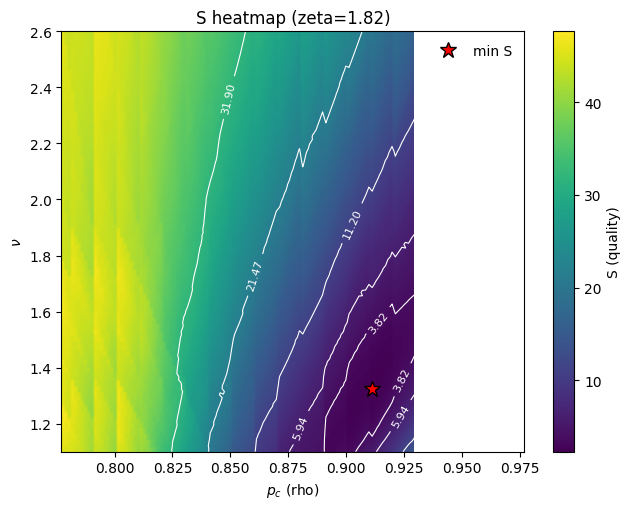

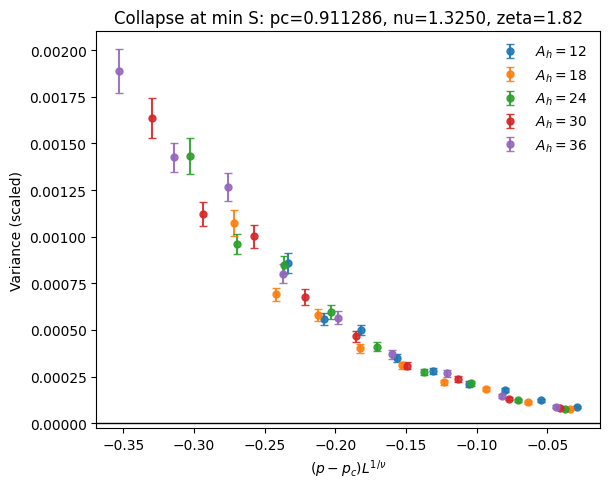

In [66]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
import numpy as np
import matplotlib.pyplot as plt
import fssa
from fssa import quality

# ========= 入力 =========
NPZ_PATH    = "from_log_var_boot.npz"
SERIES_KEYS = ["TEE2","TEE3","TEE4","TEE5","TEE6"]  # 有効サイズに対応
AH_MAP      = {"TEE1":6, "TEE2":12, "TEE3":18, "TEE4":24, "TEE5":30, "TEE6":36}
EFF_SIZE_MODE = "sqrtAh"   # "sqrtAh" or "Ah"

# ζ は固定（先に推定した値を入れる）
ZETA_VAL   = 1.82
FIX_ZETA   = True

# p（pc）グリッド設定
PC_CENTER  = 0.877    # 事前の外挿/感触に合わせて
PC_HALF_W  = 0.1     # 窓の半幅（評価にも使用）
NU_MIN, NU_MAX = 1.1, 2.6
N_PC, N_NU = 141, 141

# 数値安定化
ROUND_P = 6           # p丸め（重複/ズレ対策）
ERR_FLOOR_REL = 1e-3  # 誤差フロア（ゼロ重み回避）
MIN_COLS = 8          # そのpc窓で必要な列数の下限

# ラベル（凡例）
def eff_size(keys, mode="sqrtAh"):
    Ah = np.array([AH_MAP[k] for k in keys], float)
    return Ah if mode == "Ah" else np.sqrt(Ah)

def make_labels(keys):
    return [rf"$A_h={AH_MAP[k]}$" for k in keys]  # 例: Ah 表示

# ========= データ読み込み & 整形 =========
dat = np.load(NPZ_PATH)
pg  = np.round(dat["pg"].astype(float), ROUND_P)

A = np.array([dat[f"{k}_var"].astype(float) for k in SERIES_KEYS])  # (nL,nP)
D = np.array([dat[f"{k}_err"].astype(float) for k in SERIES_KEYS])

# p 昇順 & 同一p統合
ordr = np.argsort(pg)
pg, A, D = pg[ordr], A[:, ordr], D[:, ordr]
uniq, idx = np.unique(pg, return_inverse=True)
A2 = np.stack([np.nanmean(A[:, idx==j], axis=1) for j in range(len(uniq))], axis=1)
D2 = np.stack([np.nanmean(D[:, idx==j], axis=1) for j in range(len(uniq))], axis=1)
pg = uniq.copy()

# 誤差フロア
eps = ERR_FLOOR_REL * np.nanmedian(np.abs(A2))
D2 = np.maximum(D2, eps)

L_list = eff_size(SERIES_KEYS, EFF_SIZE_MODE).tolist()
labels = make_labels(SERIES_KEYS)

# ========= pc–ν グリッドで S を評価 =========
pc_grid = np.linspace(PC_CENTER-PC_HALF_W, PC_CENTER+PC_HALF_W, N_PC)
nu_grid = np.linspace(NU_MIN, NU_MAX, N_NU)

Smap = np.full((N_NU, N_PC), np.nan)  # 行=nu, 列=pc
best = (np.inf, None, None, None, None, None, None)  # S, pc, nu, P, xs, ys, dys

for i, nu in enumerate(nu_grid):
    for j, pc in enumerate(pc_grid):
        # pc 周りの p 列を抽出
        mask = (pg >= pc-PC_HALF_W) & (pg <= pc+PC_HALF_W)
        if mask.sum() < MIN_COLS:
            continue
        P  = pg[mask]
        Ause = A2[:, mask]
        Duse = D2[:, mask]

        # 列の健全性チェック（全Lで有限 & da>0）
        good = np.all(np.isfinite(Ause), axis=0) & np.all(np.isfinite(Duse), axis=0) & np.all(Duse > 0, axis=0)
        if good.sum() < MIN_COLS:
            continue
        P, Ause, Duse = P[good], Ause[:, good], Duse[:, good]

        # 昇順整列
        o = np.argsort(P)
        P, Ause, Duse = P[o], Ause[:, o], Duse[:, o]

        try:
            zeta = ZETA_VAL if FIX_ZETA else ZETA_VAL
            xs, ys, dys = fssa.scaledata(L_list, P, Ause, Duse, pc, nu, zeta)
            S = quality(xs, ys, dys)
            Smap[i, j] = S
            if np.isfinite(S) and S < best[0]:
                best = (S, pc, nu, P, xs, ys, dys)
        except Exception:
            # 収束失敗などは無視
            pass

S_best, pc_best, nu_best, P_best, xs_best, ys_best, dys_best = best
print("Best by grid search:")
print(f"S={S_best:.4f}, pc={pc_best:.9f}, nu={nu_best:.6f}, zeta={'fixed '+str(ZETA_VAL) if FIX_ZETA else 'free'}")
if P_best is not None:
    print(f"used p range = [{P_best.min():.6f}, {P_best.max():.6f}]  (N={len(P_best)})")

# ========= ヒートマップ描画 =========
fig, ax = plt.subplots(figsize=(6.6,5.2))
extent = [pc_grid.min(), pc_grid.max(), nu_grid.min(), nu_grid.max()]
im = ax.imshow(Smap, origin='lower', aspect='auto', extent=extent, cmap='viridis')
cbar = plt.colorbar(im, ax=ax)
cbar.set_label("S (quality)")

# 等高線（NaNを避けてパーセンタイルで）
finite = np.isfinite(Smap)
if finite.any():
    PC, NU = np.meshgrid(pc_grid, nu_grid)
    levels = np.nanpercentile(Smap[finite], [5, 10, 20, 40, 60])
    try:
        cs = ax.contour(PC, NU, Smap, levels=levels, colors='w', linewidths=0.8)
        ax.clabel(cs, fmt="%.2f", fontsize=8)
    except Exception:
        pass

# 最小点マーク
if pc_best is not None:
    ax.plot(pc_best, nu_best, marker='*', ms=12, mfc='red', mec='k', lw=0, label="min S")
ax.set_xlabel(r"$p_c$ (rho)")
ax.set_ylabel(r"$\nu$")
ax.set_title(f"S heatmap (zeta={'{:.2f}'.format(ZETA_VAL) if FIX_ZETA else 'free'})")
ax.legend(frameon=False, loc='upper right')
fig.tight_layout()
fig.savefig("S_heatmap_pc_nu.png", dpi=300, bbox_inches="tight")
plt.show()

# ========= 最良点でのコラプス図 =========
if xs_best is not None:
    fig2, ax2 = plt.subplots(figsize=(6.2,5.0))
    for i, L in enumerate(L_list):
        ax2.errorbar(xs_best.T[:, i], ys_best.T[:, i], yerr=dys_best.T[:, i],
                     fmt='o', ms=5, capsize=3, alpha=0.9, label=labels[i])
    ax2.axhline(0, color="black", lw=1)
    ax2.set_xlabel(r"$(p-p_c)L^{1/\nu}$")
    ax2.set_ylabel("Variance (scaled)")
    ax2.legend(frameon=False, fontsize=10)
    ax2.set_title(f"Collapse at min S: pc={pc_best:.6f}, nu={nu_best:.4f}, zeta={ZETA_VAL:.2f}")
    fig2.tight_layout()
    fig2.savefig("variance_collapse_at_minS.png", dpi=300, bbox_inches="tight")
    plt.show()
else:
    print("No valid (pc,nu) region produced a collapse (check window or data).")


Best by grid search (with peak-aware window):
S=22.5210, pc=0.828693136, nu=1.100000, zeta=fixed 1.82
used p range = [0.770000, 0.880000]  (N=12)
peak band ~ [0.795134, 0.819693], data range [0.70,0.90], window [0.785134,0.829693]


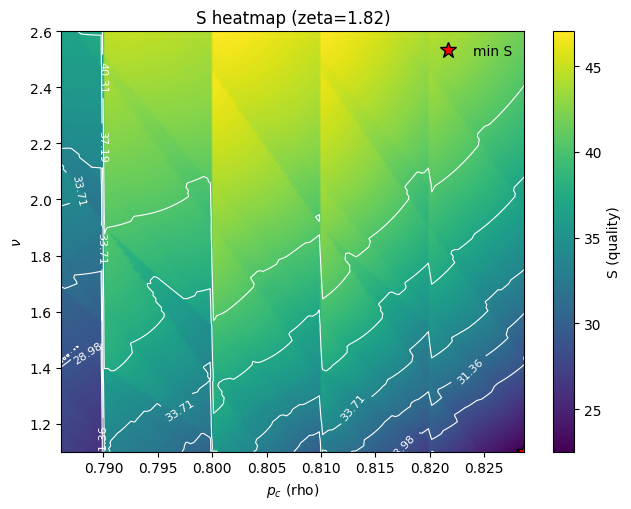

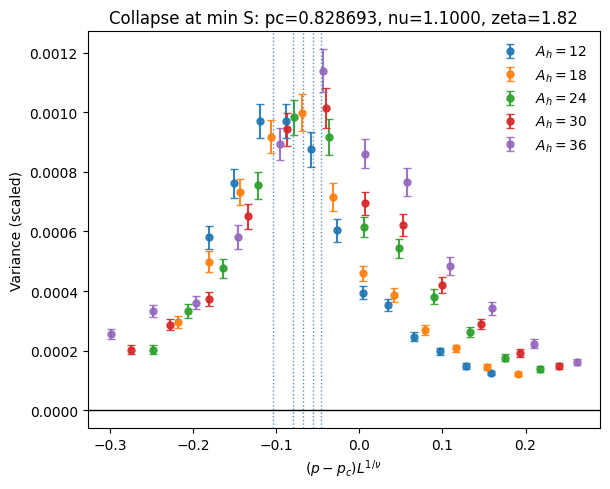

In [73]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
import numpy as np
import matplotlib.pyplot as plt
import fssa
from fssa import quality

# ========= 入力 =========
NPZ_PATH      = "from_log_var_boot.npz"
SERIES_KEYS   = ["TEE2","TEE3","TEE4","TEE5","TEE6"]  # 有効サイズに対応
AH_MAP        = {"TEE1":6, "TEE2":12, "TEE3":18, "TEE4":24, "TEE5":30, "TEE6":36}
EFF_SIZE_MODE = "sqrtAh"   # "sqrtAh" or "Ah"

# ζ は固定（ピーク高さスケールから得た値）
ZETA_VAL = 1.82
FIX_ZETA = True

# ν の探索範囲（必要に応じて微調整）
NU_MIN, NU_MAX = 1.1, 2.6
N_PC, N_NU = 141, 141

# 数値安定化
ROUND_P = 6           # p 丸め（重複/ズレ対策）
ERR_FLOOR_REL = 1e-3  # 誤差フロア（ゼロ重み回避）
MIN_COLS = 8          # 各窓で最低限ほしい列数
PC_HALF_W_MIN = 0.06  # 最小半幅（小さすぎると列不足になる）

# ========= ユーティリティ =========
def eff_size(keys, mode="sqrtAh"):
    Ah = np.array([AH_MAP[k] for k in keys], float)
    return Ah if mode == "Ah" else np.sqrt(Ah)

def quad_vertex(x0, y0, x1, y1, x2, y2):
    """3点二次の頂点 (xv,yv)。a≈0 や範囲外は中央点にフォールバック。"""
    denom = (x0-x1)*(x0-x2)*(x1-x2)
    if np.isclose(denom, 0.0): return x1, y1
    a = (x2*(y1-y0) + x1*(y0-y2) + x0*(y2-y1)) / denom
    b = (x2*x2*(y0-y1) + x1*x1*(y2-y0) + x0*x0*(y1-y2)) / denom
    if np.isclose(a, 0.0): return x1, y1
    xv = -b/(2*a)
    if not (min(x0,x2) <= xv <= max(x0,x2)): xv = x1
    yv = a*xv*xv + b*xv + (y0 - a*x0*x0 - b*x0)
    return xv, yv

def find_peak_quadratic(g, y):
    """格子上の最大点の前後3点で二次補間してピーク位置/高さを返す。端なら格子点。"""
    i = int(np.argmax(y))
    if 0 < i < len(g)-1:
        return quad_vertex(g[i-1], y[i-1], g[i], y[i], g[i+1], y[i+1])
    return g[i], y[i]

# ========= データ読み込み & 整形 =========
dat = np.load(NPZ_PATH)
pg  = np.round(dat["pg"].astype(float), ROUND_P)
A   = np.array([dat[f"{k}_var"].astype(float) for k in SERIES_KEYS])  # (nL,nP)
D   = np.array([dat[f"{k}_err"].astype(float) for k in SERIES_KEYS])

# p 昇順 & 同一p統合（丸めて束ねる）
ordr = np.argsort(pg)
pg, A, D = pg[ordr], A[:, ordr], D[:, ordr]
uniq, idx = np.unique(pg, return_inverse=True)
A2 = np.stack([np.nanmean(A[:, idx==j], axis=1) for j in range(len(uniq))], axis=1)
D2 = np.stack([np.nanmean(D[:, idx==j], axis=1) for j in range(len(uniq))], axis=1)
pg = uniq.copy()

# 誤差フロア（ゼロ重み回避）
eps = ERR_FLOOR_REL * np.nanmedian(np.abs(A2))
D2 = np.maximum(D2, eps)

L_list = eff_size(SERIES_KEYS, EFF_SIZE_MODE).tolist()
labels = [rf"$A_h={AH_MAP[k]}$" for k in SERIES_KEYS]

# ========= ピーク帯の自動検出（窓の基準） =========
# 各系列の平均曲線から二次補間でピーク位置を拾い、全体の帯域を決める
gstars = []
for i in range(len(SERIES_KEYS)):
    gx, gy = find_peak_quadratic(pg, A2[i])
    gstars.append(gx)
gstars = np.array(gstars)
DATA_MIN, DATA_MAX = pg.min(), pg.max()
PEAK_MIN, PEAK_MAX = gstars.min(), gstars.max()
MARGIN = 0.010  # 少し余裕
PAD    = 1e-3   # 端の数値ガード
WINDOW_MIN = max(DATA_MIN, PEAK_MIN - MARGIN)
WINDOW_MAX = min(DATA_MAX, PEAK_MAX + MARGIN)

# pc グリッドはピーク帯の内側に限定（データ範囲 0.70–0.90 を自動尊重）
pc_grid = np.linspace(WINDOW_MIN+PAD, WINDOW_MAX-PAD, N_PC)
nu_grid = np.linspace(NU_MIN, NU_MAX, N_NU)

# ========= グリッド評価（pcごとに半幅を自動拡張） =========
Smap = np.full((N_NU, N_PC), np.nan)  # 行=nu, 列=pc
best = (np.inf, None, None, None, None, None, None)  # S, pc, nu, P, xs, ys, dys

for i, nu in enumerate(nu_grid):
    for j, pc in enumerate(pc_grid):
        # pc でピーク帯を必ず含むよう半幅を自動決定
        w_left  = pc - WINDOW_MIN
        w_right = WINDOW_MAX - pc
        halfw   = max(PC_HALF_W_MIN, w_left, w_right)
        # データ端でもはみ出さないようクリップ
        halfw   = min(halfw, max(pc - DATA_MIN, DATA_MAX - pc))

        mask = (pg >= pc - halfw) & (pg <= pc + halfw)
        if mask.sum() < MIN_COLS:
            continue
        P  = pg[mask]
        Ause = A2[:, mask]
        Duse = D2[:, mask]

        good = np.all(np.isfinite(Ause), axis=0) & np.all(np.isfinite(Duse), axis=0) & np.all(Duse > 0, axis=0)
        if good.sum() < MIN_COLS:
            continue
        P, Ause, Duse = P[good], Ause[:, good], Duse[:, good]

        # 昇順整列
        o = np.argsort(P)
        P, Ause, Duse = P[o], Ause[:, o], Duse[:, o]

        try:
            zeta = ZETA_VAL if FIX_ZETA else ZETA_VAL
            xs, ys, dys = fssa.scaledata(L_list, P, Ause, Duse, pc, nu, zeta)
            S = quality(xs, ys, dys)
            Smap[i, j] = S
            if np.isfinite(S) and S < best[0]:
                best = (S, pc, nu, P, xs, ys, dys)
        except Exception:
            pass

S_best, pc_best, nu_best, P_best, xs_best, ys_best, dys_best = best
print("Best by grid search (with peak-aware window):")
print(f"S={S_best:.4f}, pc={pc_best:.9f}, nu={nu_best:.6f}, zeta={'fixed '+str(ZETA_VAL) if FIX_ZETA else 'free'}")
if P_best is not None:
    print(f"used p range = [{P_best.min():.6f}, {P_best.max():.6f}]  (N={len(P_best)})")
print(f"peak band ~ [{PEAK_MIN:.6f}, {PEAK_MAX:.6f}], data range [{DATA_MIN:.2f},{DATA_MAX:.2f}], window [{WINDOW_MIN:.6f},{WINDOW_MAX:.6f}]")

# ========= ヒートマップ描画 =========
fig, ax = plt.subplots(figsize=(6.6,5.2))
extent = [pc_grid.min(), pc_grid.max(), nu_grid.min(), nu_grid.max()]
im = ax.imshow(Smap, origin='lower', aspect='auto', extent=extent, cmap='viridis')
cbar = plt.colorbar(im, ax=ax); cbar.set_label("S (quality)")

finite = np.isfinite(Smap)
if finite.any():
    PC, NU = np.meshgrid(pc_grid, nu_grid)
    try:
        levels = np.nanpercentile(Smap[finite], [5, 10, 20, 40, 60])
        cs = ax.contour(PC, NU, Smap, levels=levels, colors='w', linewidths=0.8)
        ax.clabel(cs, fmt="%.2f", fontsize=8)
    except Exception:
        pass

if pc_best is not None:
    ax.plot(pc_best, nu_best, marker='*', ms=12, mfc='red', mec='k', lw=0, label="min S")
ax.set_xlabel(r"$p_c$ (rho)")
ax.set_ylabel(r"$\nu$")
ax.set_title(f"S heatmap (zeta={'{:.2f}'.format(ZETA_VAL) if FIX_ZETA else 'free'})")
ax.legend(frameon=False, loc='upper right')
fig.tight_layout()
fig.savefig("S_heatmap_pc_nu_peakaware.png", dpi=300, bbox_inches="tight")
plt.show()

# ========= 最良点でのコラプス図（ピーク位置の縦破線を表示） =========
if xs_best is not None:
    # スケール座標で各サイズのピーク位置（縦破線）
    # 先に求めた gstars は平均曲線からの二次補間ピーク
    x_peak_lines = [(gstars[i]-pc_best) * (L_list[i] ** (1.0/nu_best)) for i in range(len(L_list))]

    fig2, ax2 = plt.subplots(figsize=(6.2,5.0))
    for i, L in enumerate(L_list):
        ax2.errorbar(xs_best.T[:, i], ys_best.T[:, i], yerr=dys_best.T[:, i],
                     fmt='o', ms=5, capsize=3, alpha=0.9, label=labels[i])
        ax2.axvline(x_peak_lines[i], ls=':', lw=1, alpha=0.8)  # そのサイズのピーク位置
    ax2.axhline(0, color="black", lw=1)
    ax2.set_xlabel(r"$(p-p_c)L^{1/\nu}$")
    ax2.set_ylabel("Variance (scaled)")
    ax2.legend(frameon=False, fontsize=10)
    ax2.set_title(f"Collapse at min S: pc={pc_best:.6f}, nu={nu_best:.4f}, zeta={ZETA_VAL:.2f}")
    fig2.tight_layout()
    fig2.savefig("variance_collapse_at_minS_peakaware.png", dpi=300, bbox_inches="tight")
    plt.show()
else:
    print("No valid (pc,nu) region produced a collapse (check window or data).")


In [92]:
# === Fresh start: sizeをユーザ指定、ave/varは別ファイル、pairsは任意 ===
import numpy as np, os
from dataclasses import dataclass
from typing import Dict, Optional, List, Tuple
from scipy.interpolate import InterpolatedUnivariateSpline as Spline
from scipy.optimize import brentq
from numpy.polynomial.polynomial import polyfit

PG_KEY = "pg"       # p 軸のキー名（あなたのnpzは "pg"）
SERIES_PREFIX = "TEE"  # "TEE1_ave" 等の接頭辞

@dataclass
class Series1D:
    size: float
    p: np.ndarray
    U: np.ndarray
    dU: Optional[np.ndarray]

def _safe_load(npz_path: str):
    if not os.path.exists(npz_path):
        raise FileNotFoundError(npz_path)
    return np.load(npz_path)

def _interp_to_common_grid(p1, y1, p2, y2):
    # 2つのp配列を共通領域の等間隔グリッドへ線形補間（オーバーシュート防止）
    pmin, pmax = max(p1.min(), p2.min()), min(p1.max(), p2.max())
    if not (pmax > pmin):
        return None, None, None
    n = min(len(p1), len(p2))
    grid = np.linspace(pmin, pmax, n)
    y1g = np.interp(grid, p1, y1)
    y2g = np.interp(grid, p2, y2)
    return grid, y1g, y2g

def load_one(size_value: float, ave_path: str, var_path: str, tee_idx: int) -> Series1D:
    """サイズは引数の数値をそのまま使う。ave/varは別npzから読む。"""
    za = _safe_load(ave_path)
    zv = _safe_load(var_path)
    s = f"{SERIES_PREFIX}{tee_idx}"

    # p 軸（必須）
    pa = za[PG_KEY].astype(float)
    pv = zv[PG_KEY].astype(float)

    # 平均 & 分散（必須）
    ave = za[f"{s}_ave"].astype(float)
    var = zv[f"{s}_var"].astype(float)

    # 誤差（任意）
    dave = za.get(f"{s}_ave_err", None)
    dvar = zv.get(f"{s}_err", None)  # 分散側の誤差

    # p を共通グリッドへ（必要に応じて）
    if not (len(pa) == len(pv) and np.allclose(pa, pv)):
        ret = _interp_to_common_grid(pa, ave, pv, var)
        if ret[0] is None:
            raise RuntimeError(f"共通 p 範囲なし: {ave_path} × {var_path}")
        p, ave_g, var_g = ret
        # 誤差もあれば補間（無い方は None のまま）
        if dave is not None:
            _, dave_g, _ = _interp_to_common_grid(pa, dave.astype(float), pv, var)
        else:
            dave_g = None
        if dvar is not None:
            _, _, dvar_g = _interp_to_common_grid(pa, ave, pv, dvar.astype(float))
        else:
            dvar_g = None
        ave, var, dave, dvar = ave_g, var_g, dave_g, dvar_g
    else:
        p = pa

    # 無次元比 U とその誤差
    denom = var + ave**2
    U = var / np.where(denom > 0, denom, np.inf)

    dU = None
    if (dvar is not None) and (dave is not None):
        m = ave; d = denom
        # U = v/(v+m^2)
        # ∂U/∂v =  m^2/d^2,  ∂U/∂m = -2vm/d^2
        dU = np.sqrt( ((m**2)/(d**2) * dvar)**2 + ((-2*var*m)/(d**2) * dave)**2 )
        # 安全フロア（重み無限化の防止）
        eps = (np.nanmedian(np.abs(U))*1e-6) if np.isfinite(U).any() else 1e-8
        dU = np.where(np.isfinite(dU) & (dU > 0), dU, eps)

    print(f"[OK]  L={size_value}  p∈[{p.min():.3f},{p.max():.3f}]  n={len(p)}")
    return Series1D(size=size_value, p=p, U=U, dU=dU)

def crossing_one(a: Series1D, b: Series1D) -> Optional[Tuple[float,float,float]]:
    pmin = max(a.p.min(), b.p.min()); pmax = min(a.p.max(), b.p.max())
    if pmax <= pmin:
        return None
    fA, fB = Spline(a.p, a.U, k=3), Spline(b.p, b.U, k=3)
    g = lambda p: fA(p) - fB(p)
    grid = np.linspace(pmin, pmax, 800)
    vals = g(grid)
    idx = np.where(np.sign(vals[:-1]) * np.sign(vals[1:]) < 0)[0]
    if len(idx) == 0:
        return None
    # 交差が複数なら中央に近いもの
    from operator import itemgetter
    cands = []
    for i in idx:
        try:
            r = brentq(g, grid[i], grid[i+1])
            s = 0.5*(fA.derivative()(r) + fB.derivative()(r))  # 平均傾き
            cands.append((abs(r - 0.5*(pmin+pmax)), r, s))
        except ValueError:
            pass
    if not cands:
        return None
    _, pstar, slope = sorted(cands, key=itemgetter(0))[0]
    return pstar, slope, np.sqrt(a.size*b.size)  # (p*, slope, Leff)

def estimate_nu(rows: List[Tuple[float,float,float]]) -> float:
    # rows: (p*, slope, Leff) のリスト
    Leff = np.array([r[2] for r in rows], float)
    slope= np.array([r[1] for r in rows], float)
    mask = np.isfinite(slope) & (slope > 0)
    if mask.sum() < 2:
        raise RuntimeError("傾きデータ不足（交差ペアを増やしてください）")
    x = np.log(Leff[mask]); y = np.log(slope[mask])
    b, a = polyfit(x, y, 1)  # log s = a + b log Leff
    nu = 1.0 / b
    print(f"[RESULT] 1/nu≈{b:.6f} → nu≈{nu:.6f}")
    return nu

def estimate_pc(rows: List[Tuple[float,float,float]], nu: float) -> float:
    Leff = np.array([r[2] for r in rows], float)
    pstar= np.array([r[0] for r in rows], float)
    X = np.vstack([np.ones_like(Leff), Leff**(-1.0/nu)]).T
    coeff, *_ = np.linalg.lstsq(X, pstar, rcond=None)
    pc_hat = coeff[0]
    print(f"[RESULT] pc≈{pc_hat:.8f}  (fit vs Leff^(-1/nu))")
    return pc_hat

def p_peak_U(S: Series1D) -> float:
    sp = Spline(S.p, S.U, k=3)
    grid = np.linspace(S.p.min()+1e-6, S.p.max()-1e-6, 600)
    d = sp.derivative()(grid)
    idx = np.where(np.sign(d[:-1]) * np.sign(d[1:]) < 0)[0]
    if len(idx) == 0:
        return S.p[np.argmax(S.U)]
    cands=[]
    for i in idx:
        try:
            r = brentq(sp.derivative(), grid[i], grid[i+1])
            cands.append((sp(r), r))
        except ValueError:
            pass
    return sorted(cands, key=lambda t: -t[0])[0][1] if cands else S.p[np.argmax(S.U)]

# ======== ここだけ編集 ========
# あなたが明示的に "サイズ→ファイル" を指定（ファイル名からLを取りません）
CONFIG = {
     L : {"ave": "Lx_24_Nd_500_NT_17280_px_0.0_MPI_hexagonal6.npz","var": "from_log_var_boot.npz"},
    # 例:
    # 24 : {"ave": "Lx_24_Nd_500..._AVE.npz",           "var": "Lx_24_Nd_500..._VAR.npz"},
    # 20 : {"ave": "Lx_20_..._AVE.npz",                 "var": "Lx_20_..._VAR.npz"},
}
PAIRS = [
     (12, 18),(18, 24)
]
TEE_IDX = 2  # 使う系列（1..6）
# ==============================

def main():
    if not CONFIG:
        print("[FATAL] CONFIG が空です。サイズとファイルパスを埋めてください。"); return
    # ロード
    byL: Dict[float, Series1D] = {}
    for L, paths in CONFIG.items():
        byL[L] = load_one(float(L), paths["ave"], paths["var"], TEE_IDX)

    # ペアが無ければ初期pcの当たりを出すだけ
    if not PAIRS:
        print("[INFO] PAIRS が空。各Lの U のピーク位置を表示します。")
        for L, S in sorted(byL.items()):
            print(f"  L={L:>5}  p_peak(U)≈{p_peak_U(S):.6f}")
        return

    # 交差の抽出
    rows=[]
    for (L1, L2) in PAIRS:
        if (L1 not in byL) or (L2 not in byL):
            print(f"[WARN] 指定ペアの片方が未ロード: ({L1},{L2})"); continue
        res = crossing_one(byL[L1], byL[L2])
        if res is None:
            print(f"[INFO] 交差なし/共通p域なし: ({L1},{L2})")
            continue
        pstar, slope, Leff = res
        rows.append((pstar, slope, Leff))
        print(f"[X] pair=({L1},{L2})  p*≈{pstar:.6f}  slope≈{slope:.3e}  Leff={Leff:.3f}")

    if len(rows) < 2:
        print("[STOP] 交差ペアが足りません（最低2ペア）。")
        for L, S in sorted(byL.items()):
            print(f"  L={L:>5}  p_peak(U)≈{p_peak_U(S):.6f}")
        return

    nu_hat = estimate_nu(rows)
    pc_hat = estimate_pc(rows, nu_hat)
    print(f"[FINAL] series=TEE{TEE_IDX}  pc≈{pc_hat:.8f},  nu≈{nu_hat:.6f}")

if __name__ == "__main__":
    main()


[OK]  L=10.392304845413264  p∈[0.700,0.900]  n=21
[WARN] 指定ペアの片方が未ロード: (12,18)
[WARN] 指定ペアの片方が未ロード: (18,24)
[STOP] 交差ペアが足りません（最低2ペア）。
  L=10.392304845413264  p_peak(U)≈0.739398


In [94]:
import numpy as np
from dataclasses import dataclass
from typing import Dict, Tuple, Optional
from scipy.interpolate import InterpolatedUnivariateSpline as Spline
from numpy.polynomial.polynomial import polyfit

@dataclass
class Curve:
    L: float               # サイズ（あなたが決めた数値。ファイル名は使わない）
    p: np.ndarray          # 制御変数の配列（例：pg）
    var: np.ndarray        # 分散
    dvar: Optional[np.ndarray] = None  # 分散の誤差（なくてもOK）

def peak_pos(p: np.ndarray, y: np.ndarray) -> Tuple[float, float]:
    """スプラインでピーク位置と値を推定。単調なら素直に最大点。"""
    if len(p) < 5:
        i = np.argmax(y); return float(p[i]), float(y[i])
    sp = Spline(p, y, k=3)
    grid = np.linspace(p.min()+1e-6, p.max()-1e-6, 600)
    yg = sp(grid)
    i = int(np.argmax(yg))
    p0 = grid[i]
    # 近傍で微調整（2点内挿）
    return float(p0), float(yg[i])

def fwhm(p: np.ndarray, y: np.ndarray, y_peak: float) -> Optional[float]:
    """FWHM（半値幅）を左右で探索。片側が無ければ None。"""
    half = 0.5 * y_peak
    # 左側
    left = None
    for i in range(1, len(p)):
        if (y[i-1]-half)*(y[i]-half) <= 0:
            # 線形補間
            t = (half - y[i-1]) / (y[i]-y[i-1] + 1e-300)
            left = p[i-1] + t*(p[i]-p[i-1])
            break
    # 右側
    right = None
    for i in range(len(p)-2, -1, -1):
        if (y[i+1]-half)*(y[i]-half) <= 0:
            t = (half - y[i+1]) / (y[i]-y[i+1] + 1e-300)
            right = p[i+1] + t*(p[i]-p[i+1])
            break
    if (left is None) or (right is None) or (right <= left):
        return None
    return float(right - left)

def estimate_nu_from_width(widths: Dict[float, float]) -> float:
    """log w vs log L の傾き = -1/ν → ν を返す。"""
    Ls = np.array(sorted(widths.keys()), float)
    w  = np.array([widths[L] for L in Ls], float)
    m = (np.isfinite(w) & (w > 0))
    Ls, w = Ls[m], w[m]
    if len(Ls) < 2:
        raise RuntimeError("半値幅が2サイズ以上で取れていません。p 範囲を広げてください。")
    b, a = polyfit(np.log(Ls), np.log(w), 1)   # log w = a + b log L
    nu = -1.0 / b
    return float(nu)

def estimate_pc_from_pmax(pmax: Dict[float, float], nu: float) -> float:
    """p_max(L) = pc + a L^{-1/nu} を一次回帰で外挿。"""
    Ls  = np.array(sorted(pmax.keys()), float)
    pks = np.array([pmax[L] for L in Ls], float)
    X   = np.vstack([np.ones_like(Ls), Ls**(-1.0/nu)]).T
    pc, a = np.linalg.lstsq(X, pks, rcond=None)[0]
    return float(pc)

# ====== ここから実行例 ======
# 1) あなたの生データから、サイズごとに Curve(L, p, var, dvar) を用意してください。
#    ファイルの読み分けは各自で。ここでは例として辞書に詰めます。
# data: Dict[str, Curve] = {
#   "runA": Curve(L=16, p=pg16, var=var16, dvar=dvar16),
#   "runB": Curve(L=20, p=pg20, var=var20, dvar=dvar20),
#   "runC": Curve(L=24, p=pg24, var=var24, dvar=dvar24),
# }

def run_minimal(data: Dict[str, Curve], p_window: Optional[Tuple[float,float]] = None):
    pmax, widths = {}, {}
    for lab, cur in data.items():
        p, y = cur.p, cur.var
        if p_window is not None:
            m = (p >= p_window[0]) & (p <= p_window[1])
            p, y = p[m], y[m]
        if len(p) < 5:
            continue
        pm, ym = peak_pos(p, y)
        w = fwhm(p, y, ym)
        print(f"[{lab}] L={cur.L:>5}  p_max≈{pm:.6f}  FWHM={w if w else np.nan}")
        pmax[cur.L] = pm
        if w is not None:
            widths[cur.L] = w

    # ν：幅から
    nu = estimate_nu_from_width(widths)
    # pc：ピーク位置の外挿で
    pc = estimate_pc_from_pmax(pmax, nu)
    print(f"[RESULT] nu ≈ {nu:.6f}   pc ≈ {pc:.8f}")
    return pc, nu

# 使い方：
# pc, nu = run_minimal(data, p_window=(0.76, 0.84))  # 窓は任意。なければ None
pc, nu = run_minimal(from_log_var_boot.npz, p_window=(0.76, 0.84))

NameError: name 'from_log_var_boot' is not defined